In [38]:
import torch
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy import stats
from tqdm import tqdm

# Path setup
src_dir = os.path.join(os.path.abspath(''), '..') 
configs_dir = os.path.join(os.path.abspath(''), '../..')
sys.path.insert(0, os.path.abspath(src_dir))
sys.path.insert(0, os.path.abspath(configs_dir))

from models.autoencoder import Autoencoder
from env.inventory import InventoryManagement, DemandDistribution
from configs.experiment_config import ExperimentConfig
from utils.generate_inventory_maps import DemandDistributionConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [39]:
from utils.data_loading import QMatrixData
from models.autoencoder import trainSAE, testSAE
from models.autoencoder import Autoencoder
import importlib
importlib.reload(sys.modules['models.autoencoder'])
import math as mt

num_channels = 10
kernel_dim = 2
states = 16
in_channels = 1
inventory_dim = 8
K = 5
lr = 5e-4
batch_size = 10
gamma_sparse = 1/100*mt.sqrt(64*in_channels/K)
train_epochs = 500

In [40]:
# 1. Setup Base Directory (adjust the '..' levels to match your project structure)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) 

train_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/inventory/q matrix dictionaries/q_matricestraining_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/inventory/label dictionaries/q_matrices_labelstraining_4x4.pkl")
)


autoencoder = Autoencoder(in_channels, inventory_dim, num_channels, kernel_dim, K)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

total_losses, recon_losses, sparsity_losses, all_messages = trainSAE(
    autoencoder, train_dataset, gamma_sparse, optimizer, batch_size, train_epochs, device
)

In [41]:
import models.autoencoder
importlib.reload(models.autoencoder)
import torch

# getting messages from trained language
_, _, _, all_messages, message_dict = testSAE(autoencoder, train_dataset, batch_size, gamma_sparse, device)

In [42]:
from configs.experiment_config import ExperimentConfig
# Import the specific helper functions from your teacher module
from rl.teacher import (
    generate_q_matrices, 
    make_inventory_env, 
    compute_perfect_qdict_inventory
)
from evaluation.student_eval import train_student, run_evaluations, run_evaluations_inventory
importlib.reload(sys.modules['rl.teacher'])
importlib.reload(sys.modules['evaluation.student_eval'])

config = ExperimentConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define where your data is stored (ensure this path exists)
data_dir = "../data/inventory"  # Adjust this path as needed

# 2. Pass the required arguments: make_env, compute_perfect_qdict, and data_dir
q_matrices, label_dict, wall_state_dict, sopt_dict = generate_q_matrices(
    config, 
    device, 
    make_inventory_env,              # The 'make_env' argument
    compute_perfect_qdict_inventory, # The 'compute_perfect_qdict' argument
    data_dir                         # The 'data_dir' argument
)

# Now call the student training with the compatible dictionary
student = train_student(
    label_dict, 
    wall_state_dict, 
    sopt_dict, 
    message_dict,
    config, 
    device, 
    make_inventory_env,
    num_eps=100
)

Computing Perfect Q-Dicts:   0%|          | 0/320 [00:00<?, ?it/s]

Computing Perfect Q-Dicts: 100%|██████████| 320/320 [00:00<00:00, 11599.19it/s]


Precomputing task environments...


Precomputing tasks: 100%|██████████| 320/320 [01:45<00:00,  3.05it/s]


Training student on 320 tasks...


Student epochs:  50%|█████     | 50/100 [01:13<01:09,  1.39s/it]

    Epoch 50/100 complete


Student epochs: 100%|██████████| 100/100 [02:26<00:00,  1.46s/it]

    Epoch 100/100 complete


In [43]:
importlib.reload(sys.modules['env.inventory'])
importlib.reload(sys.modules['evaluation.student_eval'])
from evaluation.student_eval import run_evaluations, run_evaluations_inventory

# Ensure all messages are on the correct device first to avoid mid-loop crashes
message_dict_device = {k: v.to(device) for k, v in message_dict.items()}

informed_rates, misinformed_rates = run_evaluations_inventory(
    student, 
    label_dict, 
    wall_state_dict, 
    message_dict_device,
    sopt_dict, 
    config, 
    device,
    make_inventory_env
)

Evaluating Inventory:   0%|          | 0/320 [00:00<?, ?it/s]

Evaluating Inventory: 100%|██████████| 320/320 [02:44<00:00,  1.94it/s]

Informed Reward: -133.28 | Misinformed: -193.78


In [44]:
import evaluation.student_eval
importlib.reload(evaluation.student_eval)
from evaluation.student_eval import train_student_with_feedback

autoencoder, student = train_student_with_feedback(
    label_dict, 
    wall_state_dict, 
    sopt_dict, 
    q_matrices, 
    autoencoder, 
    student, 
    config, 
    device,
    make_inventory_env,
    n_transition_samples=200,
    num_eps=100
)

Precomputing task environments...


Precomputing tasks:   0%|          | 0/320 [00:00<?, ?it/s]

Precomputing tasks: 100%|██████████| 320/320 [04:06<00:00,  1.30it/s]


Joint training on 320 tasks...


Joint training epochs:  50%|█████     | 50/100 [04:01<03:22,  4.05s/it]

    Epoch 50/100 completed


Joint training epochs: 100%|██████████| 100/100 [07:20<00:00,  4.40s/it]

    Epoch 100/100 completed


In [45]:
# Extract the optimized messages generated by the newly trained Autoencoder
message_dict_feedback = {}
autoencoder.eval()
with torch.no_grad():
    for task, (wall_label, init_state, goal_state, action_mode) in label_dict.items():
        q_mat = q_matrices[task].unsqueeze(0).to(device)
        message, _ = autoencoder(q_mat)
        message_dict_feedback[(wall_label, init_state, goal_state, action_mode)] = message.squeeze(0).detach()

In [46]:
informed_rates, misinformed_rates = run_evaluations_inventory(
    student, label_dict, wall_state_dict, message_dict_feedback, sopt_dict, config, device, make_inventory_env
)

Evaluating Inventory: 100%|██████████| 320/320 [03:13<00:00,  1.66it/s]

Informed Reward: -79.02 | Misinformed: -84.05


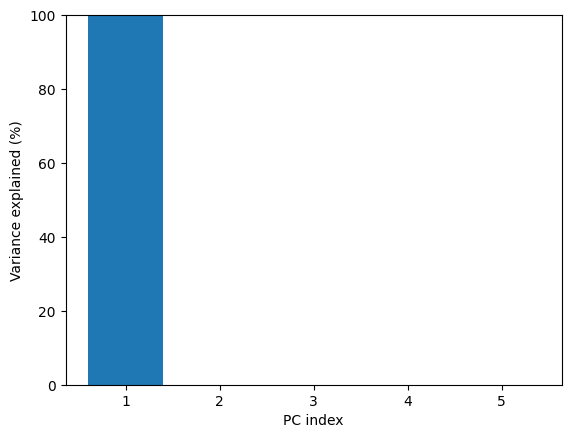

In [47]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

from utils.generate_inventory_maps import (
    DEMAND_DISTRIBUTIONS, ORDER_MODES, ORDER_MODE_TO_ID, is_train_task, INIT_STATES
)

# Reconstruct task_id → environment info by replaying the exact iteration
# order used in generate_and_save_all(). This is deterministic and must
# match the loop structure there: demand_cfg outer, order_mode middle, init_state inner.
task_env_info = {}
tid = 0
for d_idx, demand_cfg in enumerate(DEMAND_DISTRIBUTIONS):
    for o_mode in ORDER_MODES:
        if is_train_task(demand_cfg, o_mode):
            for init_state in INIT_STATES:
                task_env_info[tid] = {
                    'dist_type':     demand_cfg.dist_type,   # 'poisson' / 'uniform'
                    'category':      demand_cfg.category,    # 'low' / 'medium' / 'high'
                    'order_mode':    o_mode,                 # 'medium' / 'fine'
                    'order_mode_id': ORDER_MODE_TO_ID[o_mode],
                    'init_state':    init_state,
                }
                tid += 1


def reorder_point(q_mat, grid_dim):
    q_flat = q_mat.view(4, grid_dim ** 2)   # (4, 16)
    best_a = q_flat.argmax(dim=0)           # (16,) — best action per state
    order_states = (best_a > 0).nonzero(as_tuple=True)[0]  # states where ordering is best
    return order_states[-1].item() if len(order_states) > 0 else 0

msgs, order_mode_labels, dist_type_labels, target_inv_labels = [], [], [], []

for task_id, info in task_env_info.items():
    key = (0, info['init_state'], -1, info['order_mode_id'])
    if key not in message_dict:
        continue

    msgs.append(message_dict[key].cpu().detach().numpy())
    order_mode_labels.append(info['order_mode'])
    dist_type_labels.append(f"{info['dist_type']} ({info['category']})")
    target_inv_labels.append(reorder_point(q_matrices[task_id], config.grid_dim))

msgs_np = np.array(msgs)   # (320, K)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(msgs_np)
plot_pca_variance(pca)

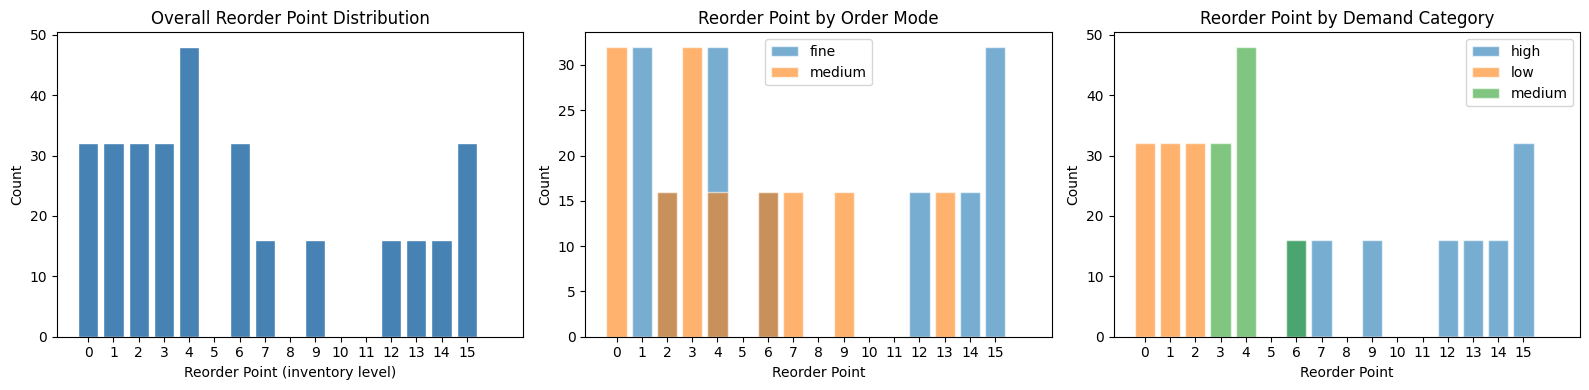

Reorder point stats — mean: 6.05, median: 4, range: [0, 15]


In [48]:
reorder_points = []
reorder_meta = []

for task_id, info in task_env_info.items():
    key = (0, info['init_state'], -1, info['order_mode_id'])
    if key not in message_dict:
        continue
    rp = reorder_point(q_matrices[task_id], config.grid_dim)
    reorder_points.append(rp)
    reorder_meta.append({**info, 'reorder_point': rp})

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Overall distribution
axes[0].hist(reorder_points, bins=range(0, config.grid_dim**2 + 2), align='left',
             color='steelblue', edgecolor='white', rwidth=0.8)
axes[0].set_xlabel('Reorder Point (inventory level)')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall Reorder Point Distribution')
axes[0].set_xticks(range(config.grid_dim**2))

# 2. By order mode
order_modes_present = sorted(set(m['order_mode'] for m in reorder_meta))
colors = plt.cm.tab10.colors
for i, mode in enumerate(order_modes_present):
    rps = [m['reorder_point'] for m in reorder_meta if m['order_mode'] == mode]
    axes[1].hist(rps, bins=range(0, config.grid_dim**2 + 2), align='left',
                 alpha=0.6, label=mode, color=colors[i], edgecolor='white', rwidth=0.8)
axes[1].set_xlabel('Reorder Point')
axes[1].set_ylabel('Count')
axes[1].set_title('Reorder Point by Order Mode')
axes[1].set_xticks(range(config.grid_dim**2))
axes[1].legend()

# 3. By demand category
categories_present = sorted(set(m['category'] for m in reorder_meta))
for i, cat in enumerate(categories_present):
    rps = [m['reorder_point'] for m in reorder_meta if m['category'] == cat]
    axes[2].hist(rps, bins=range(0, config.grid_dim**2 + 2), align='left',
                 alpha=0.6, label=cat, color=colors[i], edgecolor='white', rwidth=0.8)
axes[2].set_xlabel('Reorder Point')
axes[2].set_ylabel('Count')
axes[2].set_title('Reorder Point by Demand Category')
axes[2].set_xticks(range(config.grid_dim**2))
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary stats
print(f"Reorder point stats — mean: {np.mean(reorder_points):.2f}, "
      f"median: {np.median(reorder_points):.0f}, "
      f"range: [{min(reorder_points)}, {max(reorder_points)}]")

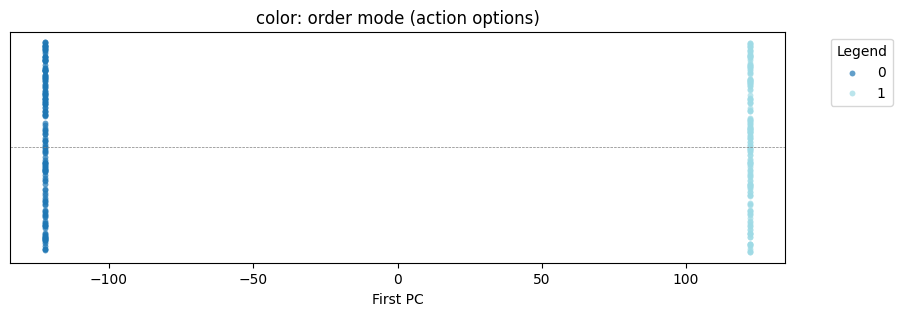

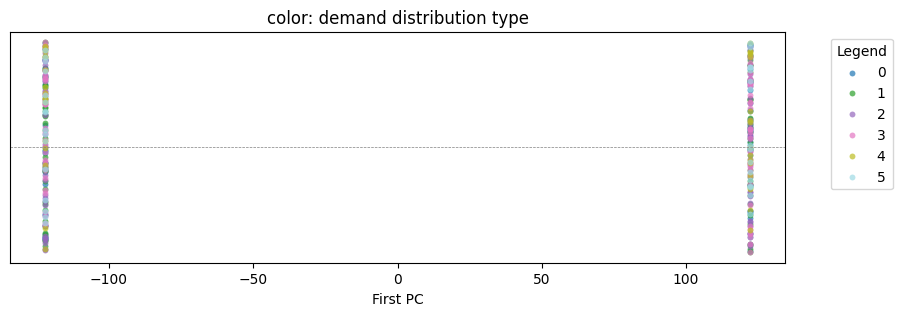

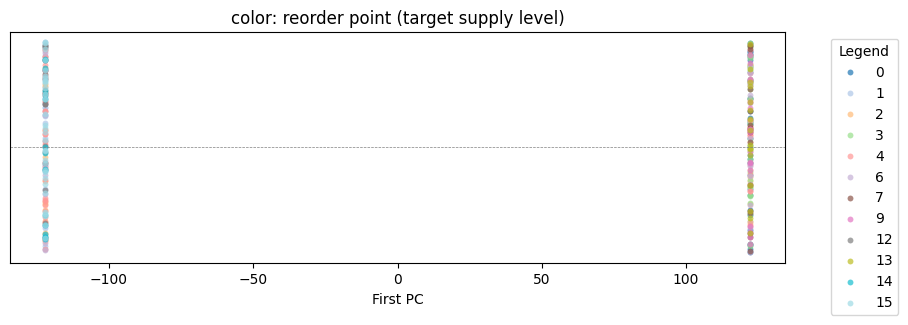

In [51]:
import utils.plotting
importlib.reload(utils.plotting)
from utils.plotting import plot_pca_1d_by_label

# convert strings to integer codes for matplotlib
unique_modes = sorted(set(order_mode_labels))
mode_codes = [unique_modes.index(l) for l in order_mode_labels]

unique_dists = sorted(set(dist_type_labels))
dist_codes = [unique_dists.index(l) for l in dist_type_labels]

plot_pca_1d_by_label(pca_result, mode_codes,  "color: order mode (action options)")
plot_pca_1d_by_label(pca_result, dist_codes,  "color: demand distribution type")
plot_pca_1d_by_label(pca_result, target_inv_labels, "color: reorder point (target supply level)")